In [2]:
# Import the necessary libraries

#libraries for data wrangling
import pandas as pd
import numpy as np

#libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

#libraries for time
from datetime import datetime, timedelta

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

#set up views
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
# Load  the data
data_path = r"archive.zip" # I am using relative path
df = pd.read_csv(data_path, low_memory=True,compression='zip') # This is how to load zipped csv file
df.tail()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
7784659,12847575,JF420478,09/01/2022 05:00:00 AM,005XX W SURF ST,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,1934,19.0,44.0,6.0,26,1172497.0,1919410.0,2022,01/03/2023 03:46:28 PM,41.934305,-87.641485,"(41.934304581, -87.641484982)"
7784660,12847801,JF420319,07/08/2022 12:00:00 AM,114XX S PRAIRIE AVE,1130,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,STREET,False,False,531,5.0,9.0,49.0,11,1179966.0,1828818.0,2022,01/03/2023 03:46:28 PM,41.685544,-87.616813,"(41.685543881, -87.616812541)"
7784661,12847324,JF420102,09/27/2022 11:00:00 AM,023XX E 70TH ST,0810,THEFT,OVER $500,RESIDENCE,False,False,331,3.0,5.0,43.0,06,1193181.0,1859005.0,2022,01/03/2023 03:46:28 PM,41.768068,-87.567453,"(41.768068052, -87.567452932)"
7784662,12847570,JF420427,09/03/2022 10:25:00 AM,052XX W CARMEN AVE,2021,NARCOTICS,POSSESS - BARBITURATES,RESIDENCE - YARD (FRONT / BACK),True,False,1623,16.0,45.0,11.0,18,1140553.0,1933418.0,2022,01/03/2023 03:46:28 PM,41.973391,-87.758535,"(41.973391184, -87.758534512)"
7784663,12840464,JF411839,09/26/2022 07:20:00 PM,0000X N MASON AVE,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,SIDEWALK,True,False,1513,15.0,29.0,25.0,15,1136773.0,1899652.0,2022,01/03/2023 03:46:28 PM,41.880802,-87.773246,"(41.880802263, -87.773245737)"


In [4]:
# df=pd.read_csv('Crimes_-_2001_to_Present.csv')

In [5]:
data = {'data':'ada','age':23,'ethnicity': 'Yoruba'}
pd.Series(data)

data            ada
age              23
ethnicity    Yoruba
dtype: object

it has 7784664 rows and 22 columns 

In [6]:
# # Lets write a function to load the full dataset (7M+ records) or just a specified samples.
# # The  idea behind this is just to reduce memory usage for the dataset to also load faster.
# # Take your time to understand the function, what I did and why I did so.

# def load_chicago_crime_data(data_path, sample_size=None):
#     """
#     Optimized loading function for Chicago crime data
#     """
#     # Define data types to reduce memory usage
#     dtype_dict = {
#         'ID': 'Int32',
#         'Case Number': 'string',
#         'IUCR': 'category',
#         'Primary Type': 'category',
#         'Description': 'category',
#         'Location Description': 'category',
#         'Arrest': 'bool',
#         'Domestic': 'bool',
#         'Beat': 'Int16',
#         'District': 'Int8',
#         'Ward': 'Int8',
#         'Community Area': 'Int8',
#         'FBI Code': 'category',
#         'X Coordinate': 'float32',
#         'Y Coordinate': 'float32',
#         'Latitude': 'float32',
#         'Longitude': 'float32'
#     }
    
#     # Parse dates during loading
#     date_cols = ['Date', 'Updated On']
    
#     if sample_size:
#         # Load random sample for faster analysis
#         df = pd.read_csv(data_path, 
#                         dtype=dtype_dict,
#                         parse_dates=date_cols,
#                         low_memory=False, keep_default_na=True, nrows = sample_size) # you can use ".sample(n=sample_size)" as well.
#     else:
#         df = pd.read_csv(data_path, 
#                         dtype=dtype_dict,
#                         parse_dates=date_cols,
#                         low_memory=False, keep_default_na=True)
#         df.to_parquet('crimes.parquet',index=False)
    
#     return df

# # I would load this and comment it out...

In [7]:
# df=load_chicago_crime_data('Crimes_-_2001_to_Present.csv')

Checking how many unique values we have in each columns 


In [8]:
print('Column Name \t\t\t\t\t number of unique rows')
for i in list(df.columns):
    unirow=df[i].nunique()
    print(f'{i}\t\t\t\t\t {unirow}')

Column Name 					 number of unique rows
ID					 7784664
Case Number					 7784121
Date					 3207478
Block					 62845
IUCR					 404
Primary Type					 36
Description					 544
Location Description					 215
Arrest					 2
Domestic					 2
Beat					 304
District					 24
Ward					 50
Community Area					 78
FBI Code					 26
X Coordinate					 79017
Y Coordinate					 130184
Year					 23
Updated On					 5561
Latitude					 889260
Longitude					 888670
Location					 890516


i want to know more about the icur and blocks ,primary type,year,fbi code,community areA, an all other columns where unique number of rows is < 200 000

In [9]:
for i in list(df.columns):
    if df[i].nunique() <= 200000 :
        print('===================================')
        print(f'     =====Unique {i} =====')
        print('===================================')

        unirow=df[i].unique()
        print(unirow)

     =====Unique Block =====
['043XX S WOOD ST' '008XX N CENTRAL AVE' '082XX S INGLESIDE AVE' ...
 '022XX N Lister Ave' '035XX N Lakewood Ave' '027XX W Logan Blvd']
     =====Unique IUCR =====
['0486' '0870' '0810' '2023' '0560' '0610' '0620' '0860' '0320' '1153'
 '0820' '0460' '2820' '0497' '1320' '1310' '031A' '0890' '0430' '2825'
 '5002' '4625' '1811' '141C' '5111' '1460' '1122' '2014' '143B' '141A'
 '1330' '0910' '2826' '1130' '2027' '0420' '0850' '2092' '2024' '1570'
 '2017' '051A' '3710' '0880' '1751' '1753' '0313' '1822' '2890' '2851'
 '0340' '502T' '1154' '1120' '2022' '143A' '1156' '1150' '4387' '1305'
 '1110' '1365' '2028' '0470' '1350' '0454' '041A' '0930' '1360' '0337'
 '1506' '0520' '5011' '1661' '3730' '2093' '1710' '502R' '0461' '0453'
 '0331' '1563' '0281' '3731' '0291' '0530' '1210' '1755' '2230' '0550'
 '0266' '1340' '0498' '1754' '1821' '2025' '1025' '4650' '3800' '5001'
 '1151' '1752' '4310' '1375' '500N' '1345' '0630' '1725' '1121' '0580'
 '031B' '1790' '502P' '225

we have 45627 unique dates which means that some incidents occured  on the same day,and time

In [10]:
def analyze_missingdata(df):
        missing_data = pd.DataFrame({
                'Column': df.columns,
                'Missing_Count': df.isnull().sum(),
                'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
                'Data_Type': df.dtypes})
        
        missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
        print("=== MISSING DATA ANALYSIS ===")
        print(missing_data)
        # Visualize missing data
        plt.figure(figsize=(12, 6))
        if not missing_data.empty:
                plt.bar(missing_data['Column'], missing_data['Missing_Percentage'])
                plt.title('Missing Data by Column')
                plt.xlabel('Columns')
                plt.ylabel('Missing Percentage (%)')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
        else:
                print("No missing data found!")
        missingcol = list(missing_data.index)
        for i in missingcol:
                if (df[i].dtype != object) and (df[i].dtype != bool and (df[i].dtype != 'category')):
                        maxval =df[i].max()
                        minval =df[i].min()
                        print('max value is : ',maxval)
                        print('min value is : ',minval)
                        print(f'mean for {i} is {df[i].mean()}')
                        print(f'median for {i} is {df[i].median()}')
                else:
                        print(f'column {i} is an object type column')

=== MISSING DATA ANALYSIS ===
                                    Column  Missing_Count  Missing_Percentage Data_Type
Ward                                  Ward         614848            7.898196   float64
Community Area              Community Area         613476            7.880571   float64
Longitude                        Longitude          86848            1.115629   float64
Latitude                          Latitude          86848            1.115629   float64
X Coordinate                  X Coordinate          86848            1.115629   float64
Y Coordinate                  Y Coordinate          86848            1.115629   float64
Location                          Location          86848            1.115629    object
Location Description  Location Description          10381            0.133352    object
District                          District             47            0.000604   float64
Case Number                    Case Number              4            0.000051    object


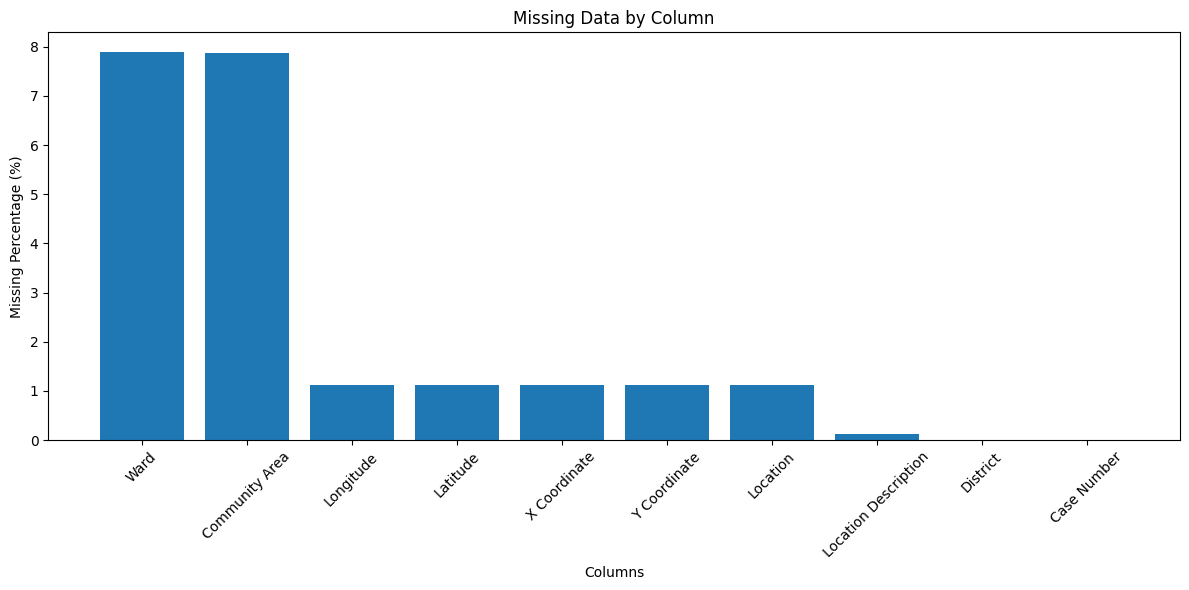

max value is :  50.0
min value is :  1.0
mean for Ward is 22.754197457786923
median for Ward is 23.0
max value is :  77.0
min value is :  0.0
mean for Community Area is 37.48472331223223
median for Community Area is 32.0
max value is :  -87.524529378
min value is :  -91.686565684
mean for Longitude is -87.67149303901755
median for Longitude is -87.66584162699999
max value is :  42.022910333
min value is :  36.619446395
mean for Latitude is 41.842183638281625
median for Latitude is 41.855907958
max value is :  1205119.0
min value is :  0.0
mean for X Coordinate is 1164601.2705625854
median for X Coordinate is 1166110.0
max value is :  1951622.0
min value is :  0.0
mean for Y Coordinate is 1885782.8573099175
median for Y Coordinate is 1890730.0
column Location is an object type column
column Location Description is an object type column
max value is :  31.0
min value is :  1.0
mean for District is 11.294659197748585
median for District is 10.0
column Case Number is an object type column


In [11]:
analyze_missingdata(df)

the mean and medians for the incomplete columns are not that far aprt so i want to fill empty cells with the mean of the column

In [12]:
def fill_missingdata(df):
        missing_data = pd.DataFrame({
                'Column': df.columns,
                'Missing_Count': df.isnull().sum(),
                'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
                'Data_Type': df.dtypes})
        
        missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
        print("=== MISSING DATA ANALYSIS ===")
        print(missing_data)
        # Visualize missing data
        plt.figure(figsize=(12, 6))
        if not missing_data.empty:
                plt.bar(missing_data['Column'], missing_data['Missing_Percentage'])
                plt.title('Missing Data by Column')
                plt.xlabel('Columns')
                plt.ylabel('Missing Percentage (%)')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
        else:
                print("No missing data found!")
        missingcol = list(missing_data.index)
        for i in missingcol:
                if (df[i].dtype != object) and (df[i].dtype != bool) and (df[i].dtype != 'category'):
                        print(f'mean for {i} is {df[i].mean()}')
                        print(f'median for {i} is {df[i].median()}')
                        df.fillna((df[i].median()))
                else:
                        print(f'column {i} is an object type column')
                        df.fillna(df[i].min())

In [13]:
fill_missingdata(df2)

NameError: name 'df2' is not defined

In [ ]:
df.dtypes

ID                               Int32
Case Number             string[python]
Date                    datetime64[ns]
Block                           object
IUCR                          category
Primary Type                  category
Description                   category
Location Description          category
Arrest                            bool
Domestic                          bool
Beat                             Int16
District                          Int8
Ward                              Int8
Community Area                    Int8
FBI Code                      category
X Coordinate                   float32
Y Coordinate                   float32
Year                             int64
Updated On              datetime64[ns]
Latitude                       float32
Longitude                      float32
Location                        object
dtype: object

In [16]:
df2 =df.copy()
df2.set_index('Date',inplace=True)

In [17]:
year= df['Year'].sort_values().unique()
year

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023])

we have records from 2001 - 2023

try finding relationship between year and  updated on

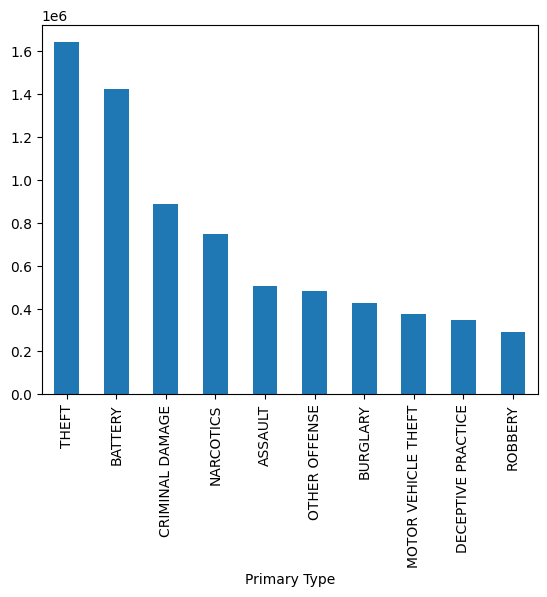

In [18]:
crimerate=df2['Primary Type'].value_counts().head(10).plot(kind='bar')

In [19]:
crimerate=df2['Primary Type'].value_counts().head(10)
crimerate

Primary Type
THEFT                  1642148
BATTERY                1422913
CRIMINAL DAMAGE         887266
NARCOTICS               747633
ASSAULT                 507296
OTHER OFFENSE           483642
BURGLARY                424397
MOTOR VEHICLE THEFT     375495
DECEPTIVE PRACTICE      344940
ROBBERY                 292334
Name: count, dtype: int64

In [20]:
print(list(df['Primary Type'].unique()))

['BATTERY', 'THEFT', 'NARCOTICS', 'ASSAULT', 'BURGLARY', 'ROBBERY', 'DECEPTIVE PRACTICE', 'OTHER OFFENSE', 'CRIMINAL DAMAGE', 'WEAPONS VIOLATION', 'CRIMINAL TRESPASS', 'MOTOR VEHICLE THEFT', 'SEX OFFENSE', 'INTERFERENCE WITH PUBLIC OFFICER', 'OFFENSE INVOLVING CHILDREN', 'PUBLIC PEACE VIOLATION', 'PROSTITUTION', 'GAMBLING', 'CRIM SEXUAL ASSAULT', 'LIQUOR LAW VIOLATION', 'CRIMINAL SEXUAL ASSAULT', 'ARSON', 'STALKING', 'KIDNAPPING', 'INTIMIDATION', 'CONCEALED CARRY LICENSE VIOLATION', 'NON - CRIMINAL', 'HUMAN TRAFFICKING', 'OBSCENITY', 'PUBLIC INDECENCY', 'OTHER NARCOTIC VIOLATION', 'NON-CRIMINAL', 'HOMICIDE', 'NON-CRIMINAL (SUBJECT SPECIFIED)', 'RITUALISM', 'DOMESTIC VIOLENCE']


In [ ]:
incitype=['THEFT','BATTERY','CRIMINAL DAMAGE','NARCOTICS','DECEPTIVE PRACTICE']
for i in incitype:
    if i in list(df['Primary Type'].unique()):
        return df2[df2['Primary Type']==i]
        
    else:
        print('not found')


In [34]:
theftdata= df2[df2['Primary Type']=='THEFT']

In [37]:
arrestcaegory=theftdata['Arrest'].value_counts()

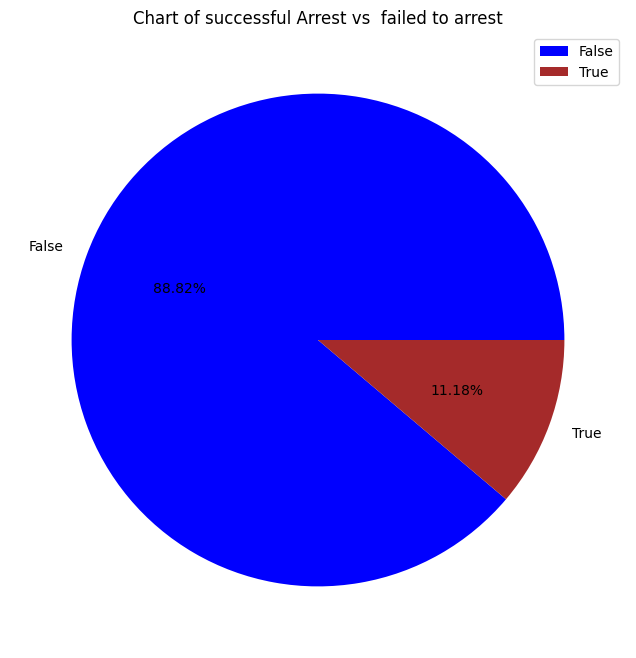

In [43]:
plt.figure(figsize=(8,8))
plt.pie(arrestcaegory.values,labels=arrestcaegory.index,colors=['blue','Brown'],autopct='%.2f%%')
plt.title('Chart of successful Arrest vs  failed to arrest')
plt.legend()
plt.show()

<Axes: xlabel='Primary Type'>

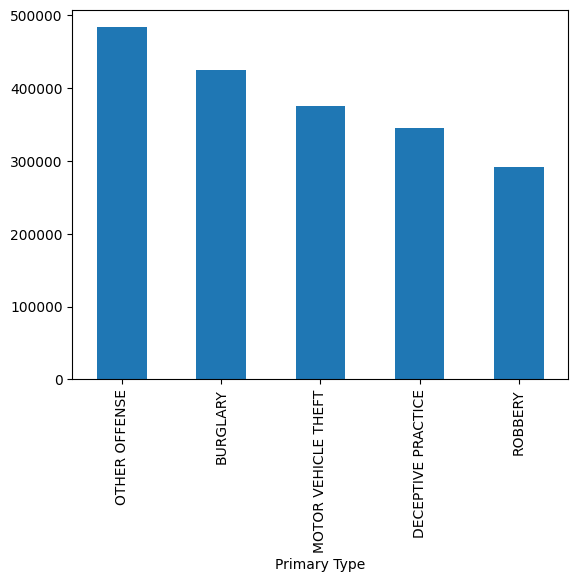

In [45]:
crimerate.tail().plot(kind='bar')

these are the offenses/incidents that happens the least 

In [ ]:
# df2.groupby(['Year'])['ID', 'Case Number', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code' 'Updated On', 'Latitude', 'Longitude', 'Location']
countbyyear=df2.groupby('Year')['Primary Type'].value_counts()
countbyhead=countbyyear.groupby(level=0).head()
countbyhead2=countbyhead.unstack(level='Primary Type',fill_value=0)

<Figure size 1000x1000 with 0 Axes>

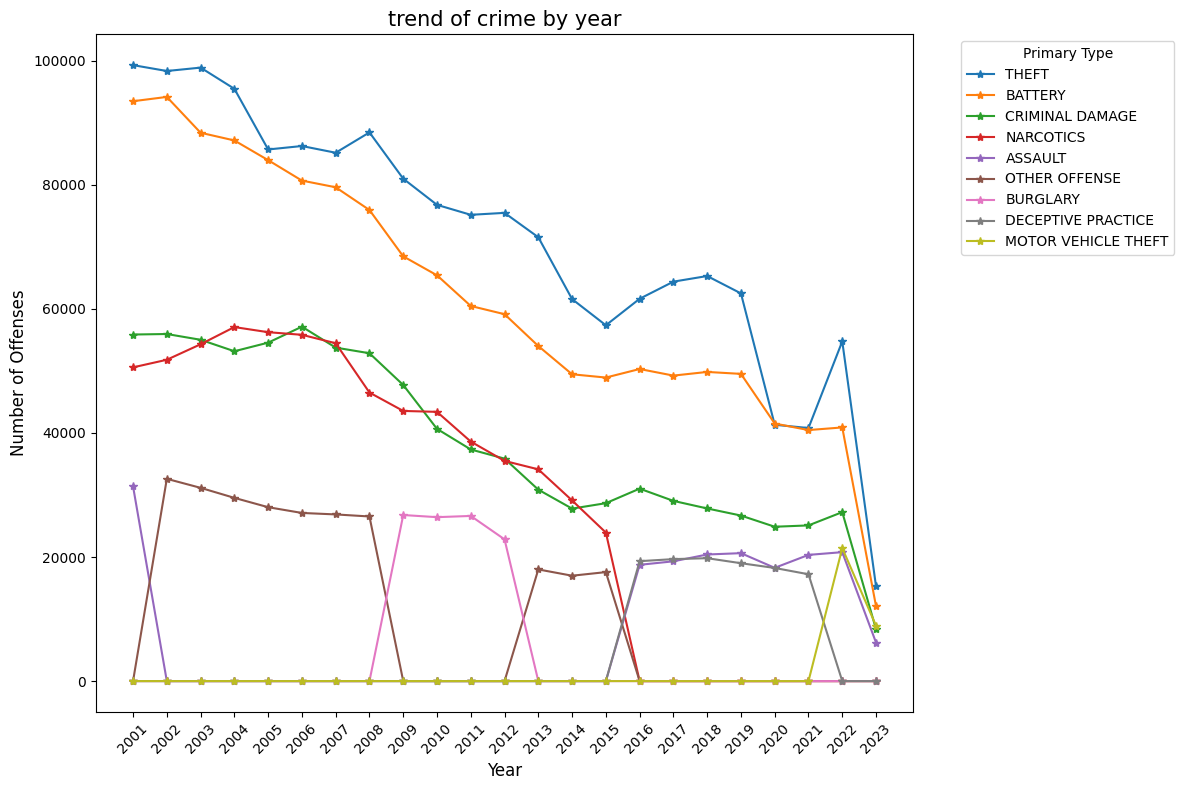

In [ ]:
plt.figure(figsize=(10,10))
fig,ax =plt.subplots(figsize=(12,8))
countbyhead2.plot(ax=ax,marker='*')
ax.set_title('trend of crime by year',fontsize=15)
ax.set_xlabel('Year',fontsize=12)
ax.set_ylabel('Number of Offenses',fontsize=12)
ax.set_xticks(countbyhead2.index)
ax.tick_params(axis='x',rotation=45)
plt.legend(title='Primary Type',bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

this is the trend of for crime with year 

there was little to no motor vehicle theft since 2001 till 2021 when there was a sudden spike

theft was significantly high in the yeaar 2001 but it dropped drastically over the years .which is the same for most of the top crimes 

In [101]:
df2['Primary Type'].nunique()

36

# descriptive statistics 

now that there was a drop in the occurence of these offenses over the years it must have been because of something .what could have influenced this ?

now i want to do a correlation analysis of all the columns and see which ones have the best correlation ...

my guess is that the number of arrest played a big role in this,but never say never it could be something else 

In [ ]:
df2['Arrest'].value_counts()
countbyhead
#find correlation between this two variables 

Primary Type,THEFT,BATTERY,CRIMINAL DAMAGE,NARCOTICS,ASSAULT,OTHER OFFENSE,BURGLARY,DECEPTIVE PRACTICE,MOTOR VEHICLE THEFT
Year,,,,,,,,,
2001,99277,93460,55858,50567,31384,0,0,0,0
2002,98331,94153,55941,51789,0,32600,0,0,0
2003,98876,88379,55011,54288,0,31147,0,0,0
2004,95463,87136,53164,57060,0,29532,0,0,0
2005,85684,83964,54548,56234,0,28028,0,0,0
2006,86240,80666,57124,55813,0,27101,0,0,0
2007,85156,79593,53749,54454,0,26863,0,0,0
2008,88435,75926,52842,46507,0,26533,0,0,0
2009,80975,68460,47725,43542,0,0,26767,0,0
